# Load Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

In [5]:
# Load data files
MC_4S_comb = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_3.root:MC_e_comb'],
                          library="pd",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_comb = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_3.root:Data_e_comb'],
                          library="pd",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

# df_mc_4S_comb = pd.DataFrame(MC_4S_comb)
# df_data_4S_comb = pd.DataFrame(data_4S_comb)

In [6]:
MC_4S_comb=util.apply_pid_corrections(df=MC_4S_comb, run='run2', channel='e', corr_col_name='total_PIDweight')

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_charge', 'ell_BFbrems_p', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_charge', 'K_p', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_charge', 'pi1_p', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_charge', 'pi2_p', 'pi2_PDG', 'pi2_mcPDG']


In [5]:
# # Load the PID weights saved from systematic correction framework
# from sysvar import add_weights_to_dataframe

# add_weights_to_dataframe(
#     df = df_mc_4S_comb,
#     systematic= "eID_eff",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_eff_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_comb,
#     systematic= "eID_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# # add_weights_to_dataframe(
# #     df = df_mc_4S_loose,
# #     systematic= "KID_eff",
# #     MC_production= "MC15rd",
# #     prefix= "D_K",
# #     weightname ="KID_eff_weight",
# #     #overwrite: False,
# #     #Nvar: 0
# # )

# # add_weights_to_dataframe(
# #     df = df_mc_4S_loose,
# #     systematic= "KID_fake",
# #     MC_production= "MC15rd",
# #     prefix= "D_K",
# #     weightname ="KID_fake_weight",
# #     #overwrite: False,
# #     #Nvar: 0
# # )

# # if multiple correction weights exist, combine them
# df_mc_4S_comb["total_PID_weight"] = df_mc_4S_comb[["ell_eID_eff_weight", "ell_eID_fake_weight",]].product(axis = 1)

In [7]:
samples_comb=util.classify_mc_dict(MC_4S_comb, 'e', template=False)
mpl_comb=util.mpl(samples_comb,data_4S_comb)
for name, df in samples_comb.items():
    print(name, len(df))

bkg_fakeD 108009
bkg_fakeL 1707
bkg_fakeTracks 3403
bkg_continuum 6387
bkg_combinatorial 49066
bkg_hadronicB_secondaryL 10181
bkg_other_TDTl 0
$D\tau\nu$ 324
$D^\ast\tau\nu$ 227
$D\ell\nu$ 3351
$D^\ast\ell\nu$ 3473
$D^{\ast\ast}\tau\nu$ 402
$D^{\ast\ast}\ell\nu$_narrow 2590
$D^{\ast\ast}\ell\nu$_broad 1905
$D\ell\nu$_gap 4125
bkg_other_signal 0



[bkg_combinatorial] N=49066  sum(BB_weight)=25516.257
D_category
BBbar_measured_hadronic     22366.159942
BBbar_unmeasured:4-body      6204.450000
BBbar_semileptonic           4156.000000
BBbar_unmeasured:2-body       893.000000
BBbar_unmeasured:3-body       595.760000
BBbar_unmeasured:5+-body      134.310000
Name: D_side_weight, dtype: float64


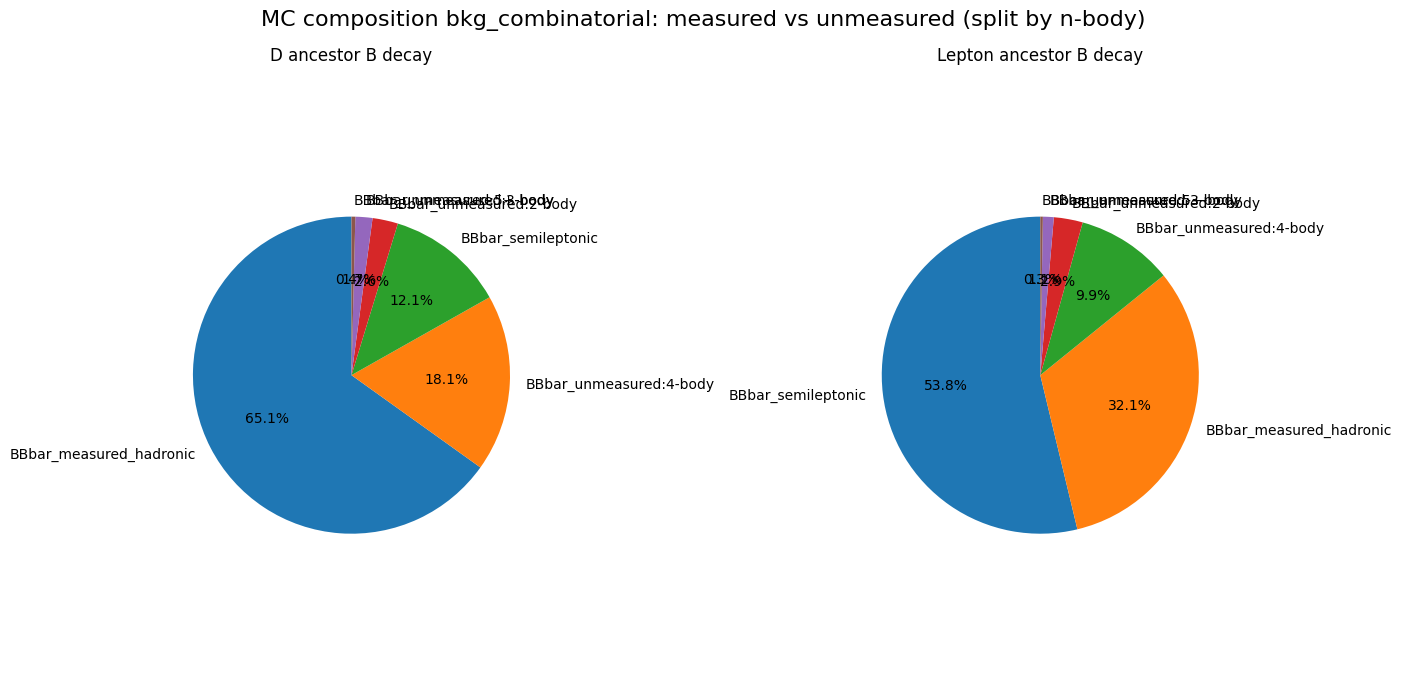


[bkg_hadronicB_secondaryL] N=10181  sum(BB_weight)=9227.469
D_category
BBbar_measured_hadronic     7257.279419
BBbar_unmeasured:4-body     1326.390000
BBbar_unmeasured:2-body      380.760000
BBbar_unmeasured:3-body      183.520000
BBbar_semileptonic            70.000000
BBbar_unmeasured:5+-body       9.520000
Name: D_side_weight, dtype: float64


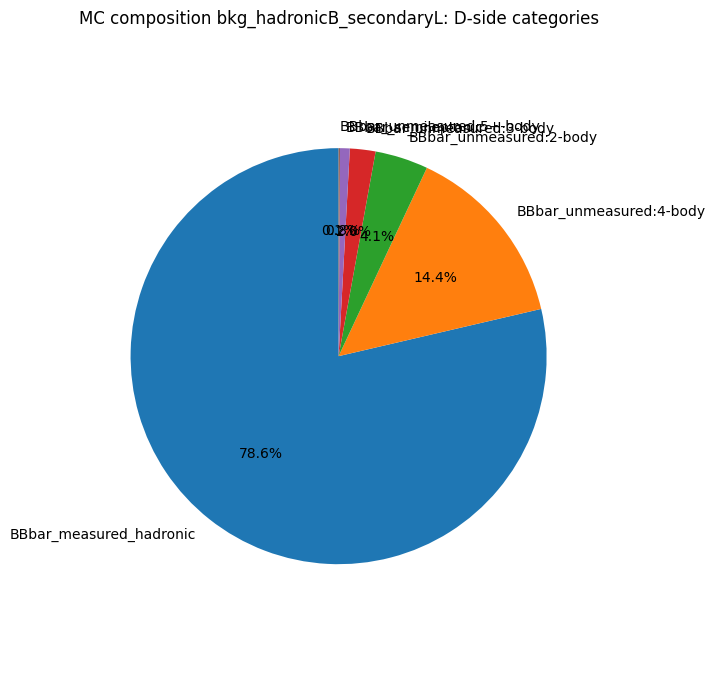

In [11]:
weights={'BBbar_measured_hadronic':2.08,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':0.76,
         'BBbar_unmeasured:3-body':0.08,
         'BBbar_unmeasured:4-body':0.57,
         'BBbar_unmeasured:5+-body':0.01,}

samples_comb_sub = util.reweight_BBbar_background(samples_comb, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = True, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = None, ell_replacement_map = None)
for name, df in samples_comb_sub.items():
    df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
mpl_comb_sub=util.mpl(samples_comb_sub,data_4S_comb)

[D_] Missing weight_map keys, defaulting to 1: ['BBbar_unmeasured:5+-body']
[D_] many-to-one replacement [7886494461] -> 4488003: N_old=231.000, N_new=43.000, R=6.372
[D_] many-to-one replacement [7923090723] -> 4508829: N_old=242.000, N_new=73.000, R=4.315
[D_] many-to-one replacement [2182554261] -> 8798003: N_old=229.000, N_new=9.000, R=26.444
[D_] many-to-one replacement [2192682123] -> 8838829: N_old=195.000, N_new=15.000, R=14.000
[D_] many-to-one replacement [19662651] -> 178865: N_old=170.000, N_new=107.000, R=2.589
[D_] many-to-one replacement [19753893] -> 179695: N_old=178.000, N_new=109.000, R=2.633
[D_] many-to-one replacement [37376751] -> 183175: N_old=167.000, N_new=111.000, R=2.505
[D_] many-to-one replacement [37550193] -> 184025: N_old=210.000, N_new=90.000, R=3.333
[D_] many-to-one replacement [4148819361] -> 8802313: N_old=142.000, N_new=3.000, R=48.333
[D_] many-to-one replacement [4168071423] -> 8843159: N_old=196.000, N_new=18.000, R=11.889

[bkg_combinatorial] 

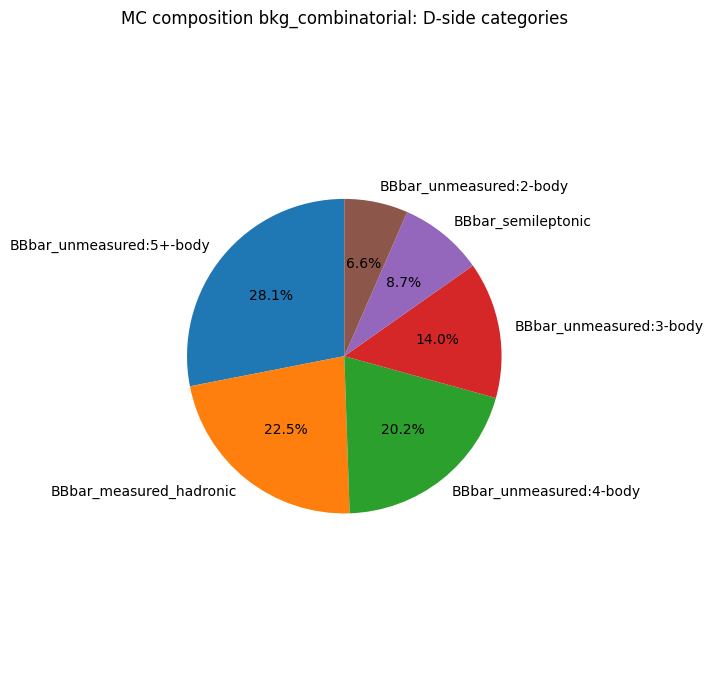

[D_] Missing weight_map keys, defaulting to 1: ['BBbar_unmeasured:5+-body']
[D_] many-to-one replacement [7886494461] -> 4488003: N_old=72.000, N_new=17.000, R=5.235
[D_] many-to-one replacement [7923090723] -> 4508829: N_old=92.000, N_new=38.000, R=3.421
[D_] many-to-one replacement [2182554261] -> 8798003: N_old=98.000, N_new=1.000, R=99.000
[D_] many-to-one replacement [2192682123] -> 8838829: N_old=91.000, N_new=3.000, R=31.333
[D_] many-to-one replacement [19662651] -> 178865: N_old=97.000, N_new=45.000, R=3.156
[D_] many-to-one replacement [19753893] -> 179695: N_old=70.000, N_new=52.000, R=2.346
[D_] many-to-one replacement [37376751] -> 183175: N_old=148.000, N_new=64.000, R=3.312
[D_] many-to-one replacement [37550193] -> 184025: N_old=135.000, N_new=78.000, R=2.731
[D_] many-to-one replacement [4148819361] -> 8802313: N_old=124.000, N_new=6.000, R=21.667
[D_] many-to-one replacement [4168071423] -> 8843159: N_old=123.000, N_new=14.000, R=9.786

[bkg_hadronicB_secondaryL] N=10

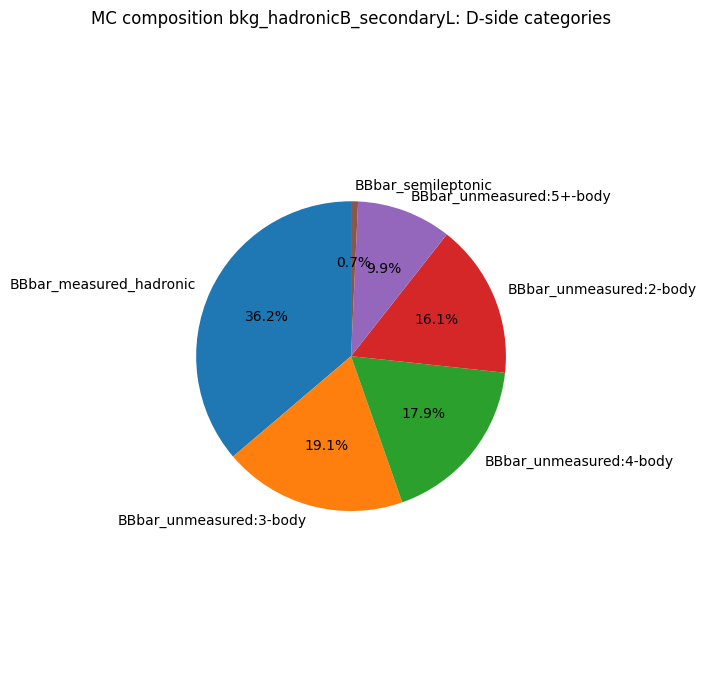

In [6]:
weights={'BBbar_measured_hadronic':1,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':1,
         'BBbar_unmeasured:3-body':1,
         'BBbar_unmeasured:4-body':1,
         'BBbar_unmeasured:5-body':1,
         'BBbar_unmeasured:6-body':1,
         'BBbar_unmeasured:7-body':1,}

D_replacement_map = {431 * 411 * 211 * 211: 431 * 10413,  # Ds D pi pi -> Ds D1
                     433 * 411 * 211 * 211: 433 * 10413,  # Ds* D pi pi -> Ds* D1
                     431 * 411 * 111 * 111: 431 * 20413,  # Ds D pi0 pi0 -> Ds D1'        415/10413    D2*/D1
                     433 * 411 * 111 * 111: 433 * 20413,  # Ds* D pi0 pi0 -> Ds* D1'      415/10413    D2*/D1
                     431 * 411 * 111: 431 * 415,          # Ds D pi0 -> Ds D2*
                     433 * 411 * 111: 433 * 415,          # Ds* D pi0 -> Ds* D2*
                     431 * 411 * 211: 431 * 425,          # Ds D pi -> Ds D2*
                     433 * 411 * 211: 433 * 425,          # Ds* D pi -> Ds* D2*
                     431 * 411 * 211 * 111: 431 * 20423,  # Ds D pi pi0 -> Ds D1'         425/10423    D2*/D1
                     433 * 411 * 211 * 111: 433 * 20423,  # Ds* D pi pi0 -> Ds* D1'       425/10423    D2*/D1
                    }

samples_comb_sub = util.reweight_BBbar_background(samples_comb, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = False, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = D_replacement_map)
for name, df in samples_comb_sub.items():
    df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
mpl_comb_sub=util.mpl(samples_comb_sub,df_data_4S_comb)

In [ ]:
print('D mother B hadronic decay 1 charm, mixed') 
DHad1Charm.query('D_511_0_daughterPDG!=-1')[['abs_D_511_0_daughterPDG','abs_D_511_1_daughterPDG','abs_D_511_2_daughterPDG',
                'abs_D_511_3_daughterPDG','abs_D_511_4_daughterPDG','abs_D_511_5_daughterPDG',]].value_counts().to_frame()[35:55]

In [24]:
len(ellSec.query('abs_ell_genMotherPDG!=22 and abs_ell_genMotherPDG!=111'))

65145

In [ ]:
ellSec[['abs_ell_genMotherPDG','abs_ell_genGMPDG',]].value_counts().to_frame().head(15)

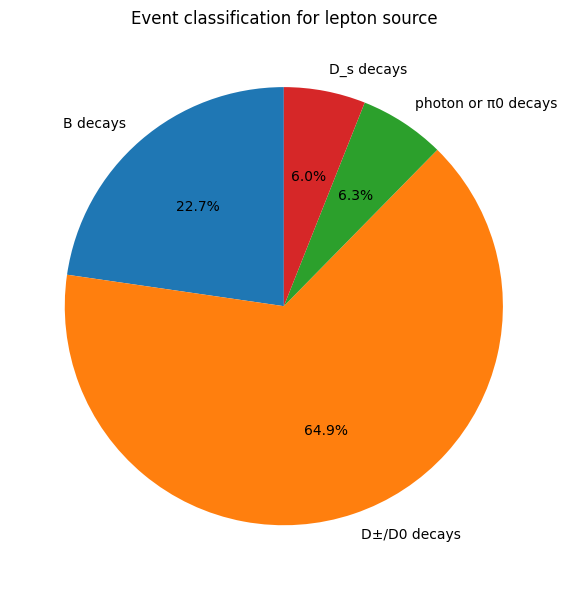

In [25]:
plt.figure(figsize=(6, 6))

plt.pie(
    [591+9889+15309,32180+13033+10685+8033+3656+3175+2993, 5768++821+605,4326+1516+994],
    labels=['B decays','D±/D0 decays', 'photon or π0 decays', 'D_s decays'],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Event classification for lepton source")
plt.tight_layout()
plt.show()

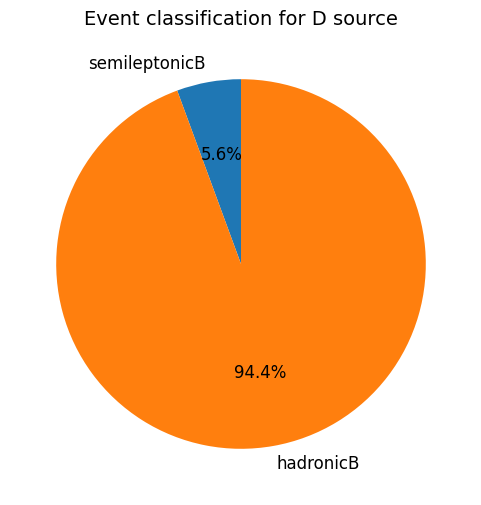

In [16]:
# Example data
sizes = [6950, 116910]  # Portion sizes for each component
labels = ['semileptonicB', 'hadronicB']  # Names of each component

# Plotting the pie chart
plt.figure(figsize=(6, 6))  # Optional: adjust the size of the figure
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 12})
plt.title('Event classification for D source', fontsize=14)
plt.show()

In [14]:
samples_comb['SemileptonicB2D_SecondaryLepton + HadronicB2D_PrimaryLepton'].ell_mcSecPhysProc.value_counts(dropna=False)

ell_mcSecPhysProc
0.0     7321
16.0      18
Name: count, dtype: int64

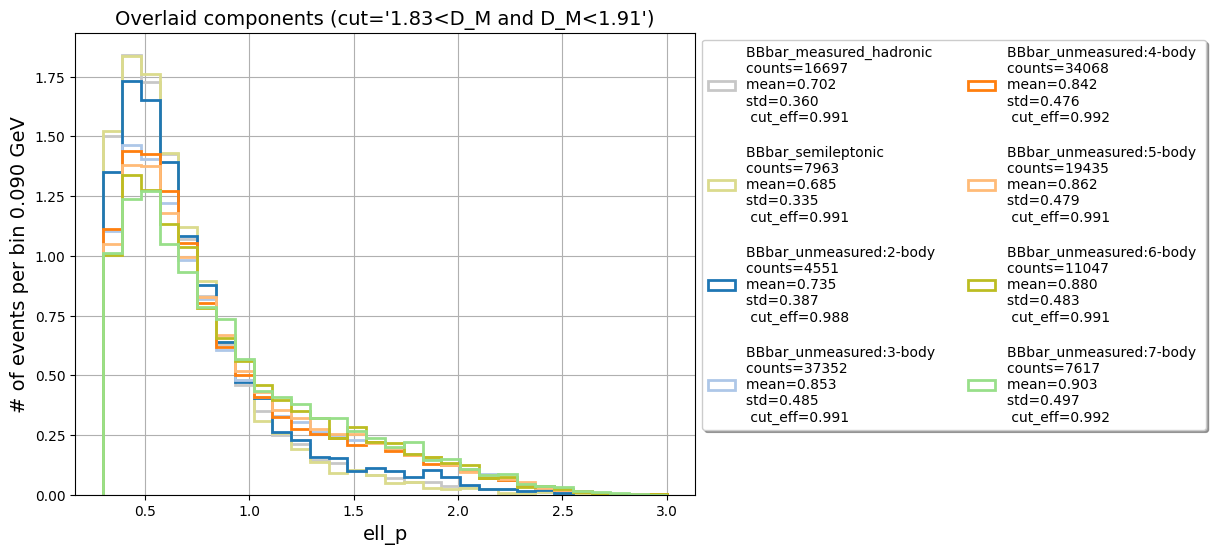

In [68]:
b1 = np.linspace(0.3,3,31)
comb_conpon = ['BBbar_measured_hadronic', 'BBbar_semileptonic', 'BBbar_unmeasured:2-body', 'BBbar_unmeasured:3-body',
         'BBbar_unmeasured:4-body', 'BBbar_unmeasured:5-body', 'BBbar_unmeasured:6-body', 'BBbar_unmeasured:7-body',]
mpl_comb_sub.plot_mc_1d_overlaid(variable='ell_p',bins=b1,mask=[],cut='1.83<D_M and D_M<1.91',
                        show_only=comb_conpon,density=True,legend_nc=2)

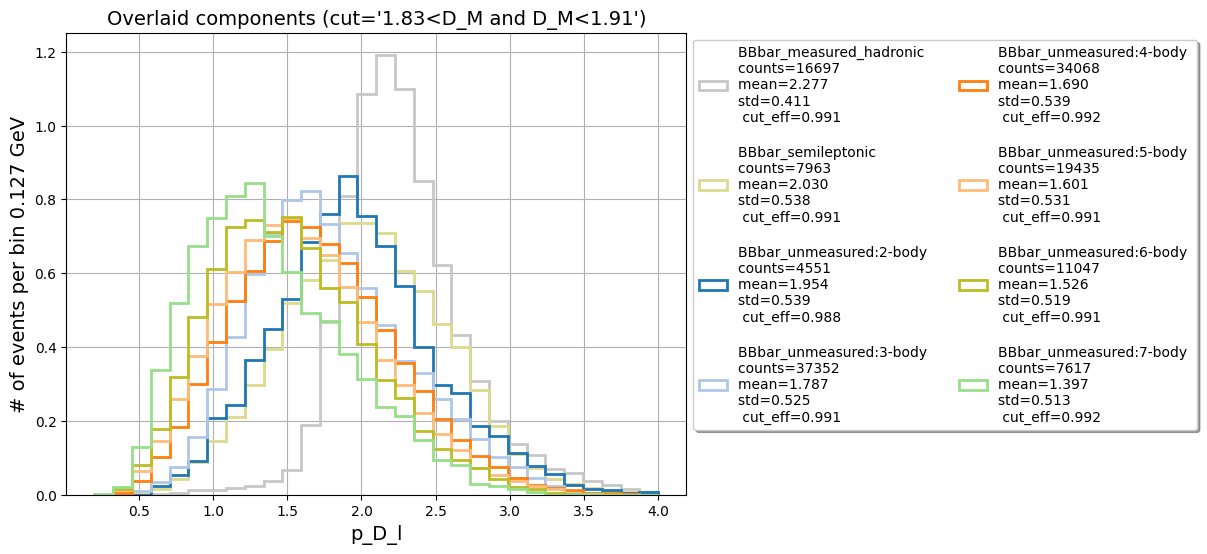

In [69]:
b1 = np.linspace(0.2,4,31)
comb_conpon = ['BBbar_measured_hadronic', 'BBbar_semileptonic', 'BBbar_unmeasured:2-body', 'BBbar_unmeasured:3-body',
         'BBbar_unmeasured:4-body', 'BBbar_unmeasured:5-body', 'BBbar_unmeasured:6-body', 'BBbar_unmeasured:7-body',]
mpl_comb_sub.plot_mc_1d_overlaid(variable='p_D_l',bins=b1,mask=[],cut='1.83<D_M and D_M<1.91',
                        show_only=comb_conpon,density=True,legend_nc=2)

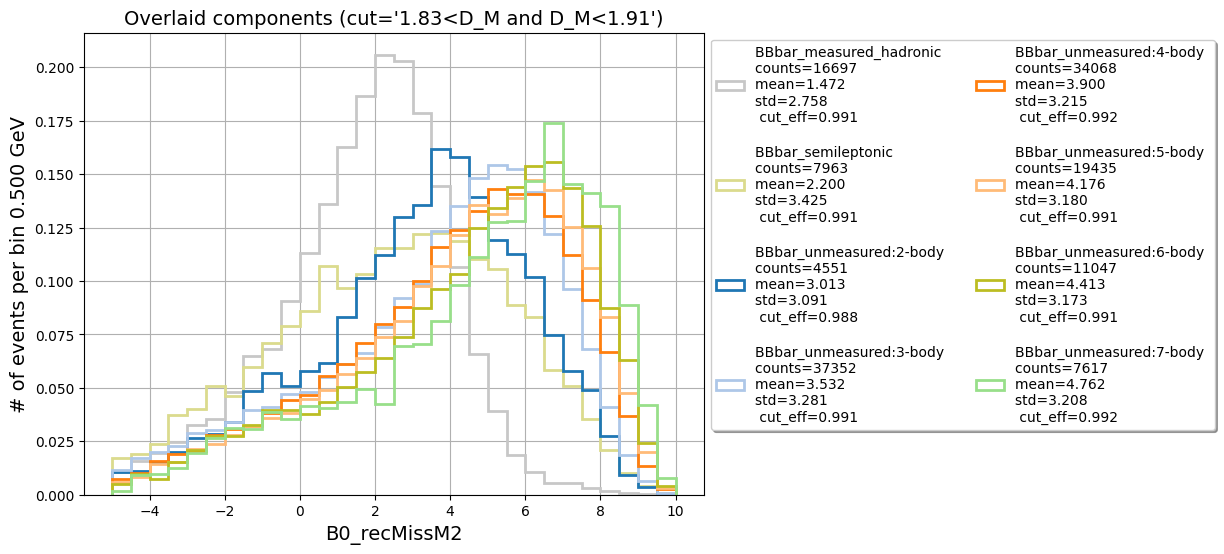

In [70]:
b1 = np.linspace(-5,10,31)
comb_conpon = ['BBbar_measured_hadronic', 'BBbar_semileptonic', 'BBbar_unmeasured:2-body', 'BBbar_unmeasured:3-body',
         'BBbar_unmeasured:4-body', 'BBbar_unmeasured:5-body', 'BBbar_unmeasured:6-body', 'BBbar_unmeasured:7-body',]
mpl_comb_sub.plot_mc_1d_overlaid(variable='B0_recMissM2',bins=b1,mask=[],cut='1.83<D_M and D_M<1.91',
                        show_only=comb_conpon,density=True,legend_nc=2)

# Control regions
## 1. BDT comb region and B0_vtxReChi2>3
### a. Plot data vs MC

cut= fakeD_prob<0.1 and sig_prob<0.1


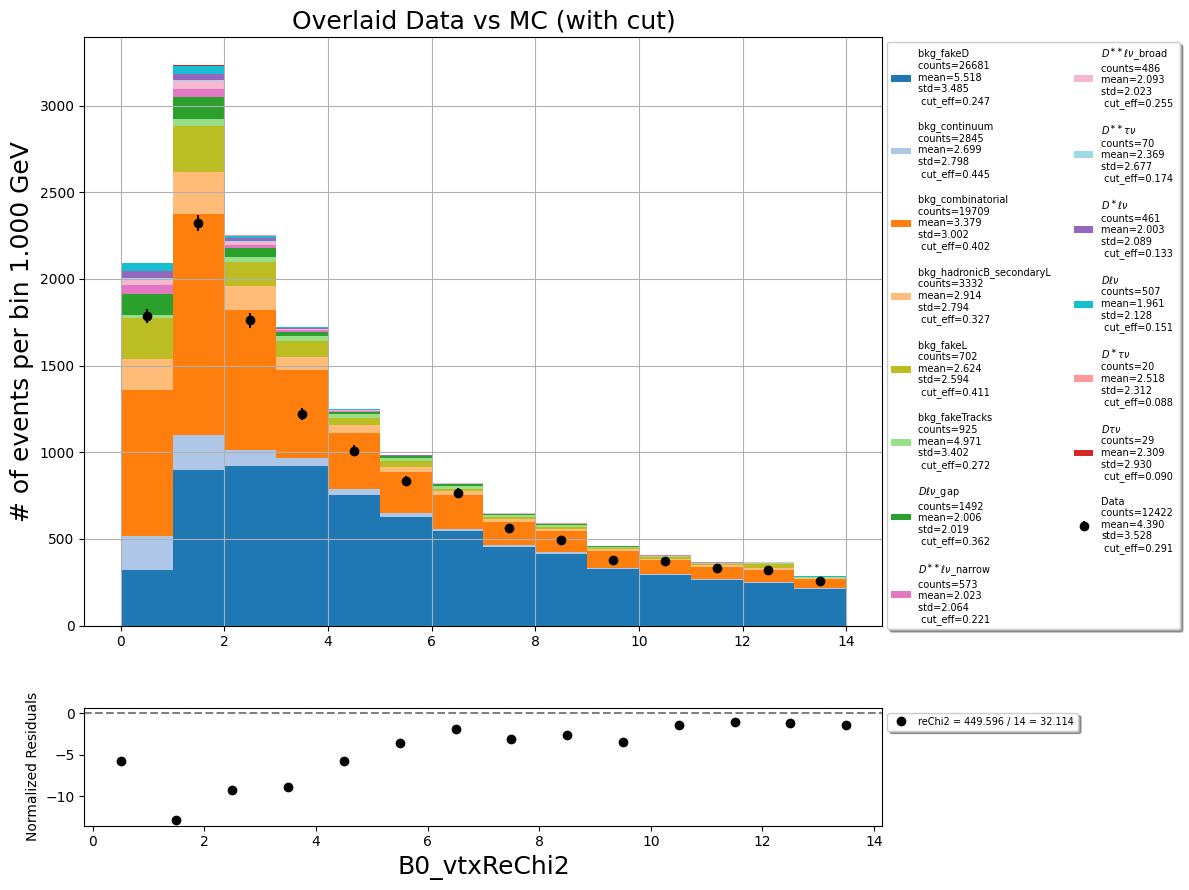

In [15]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0,14,15)
weights={'all_mc':0.25 * 1.029,}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='B0_vtxReChi2',bins=b1,cut='fakeD_prob<0.1 and sig_prob<0.1',mask=[],figsize=(12,9),ratio=False,
    legend_nc=2,legend_fs=7,text_fs=18,weights=weights,apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


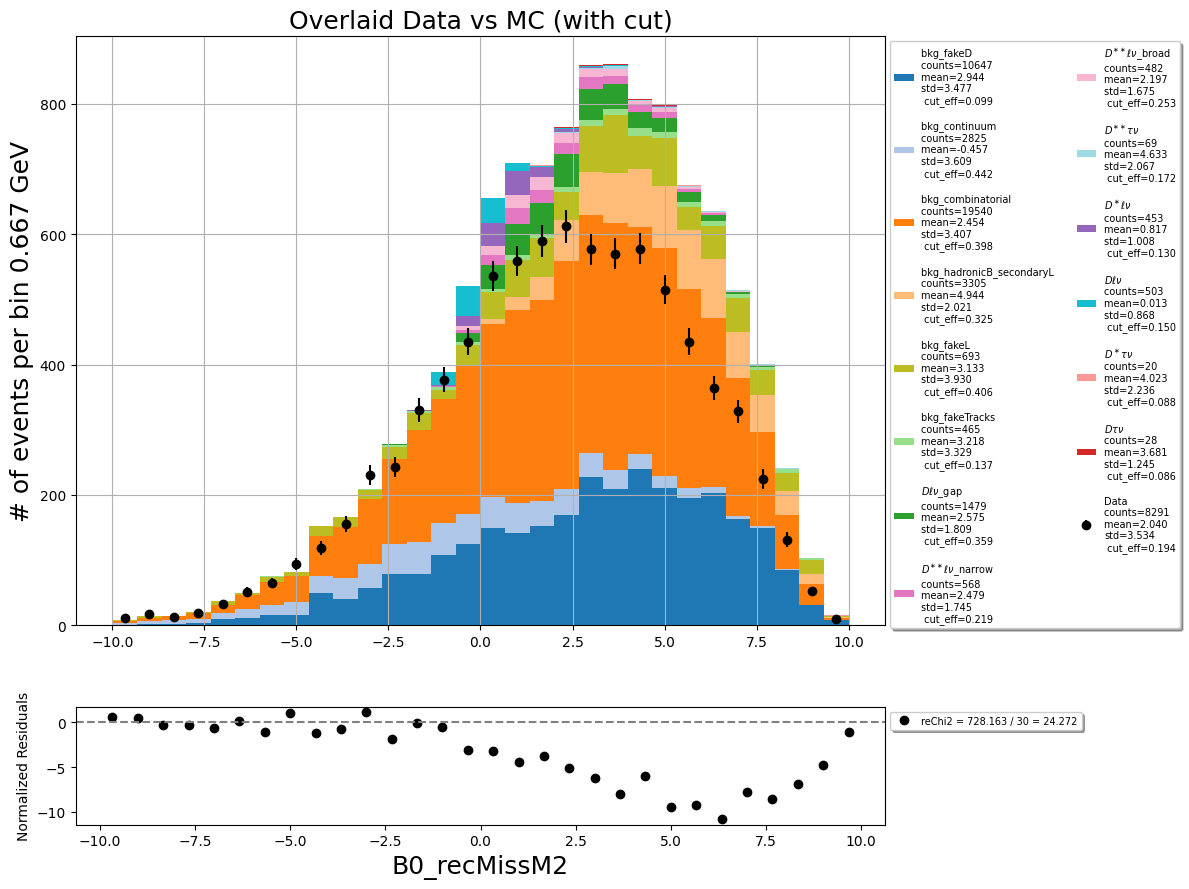

In [16]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PIDweight'

cut= (D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1


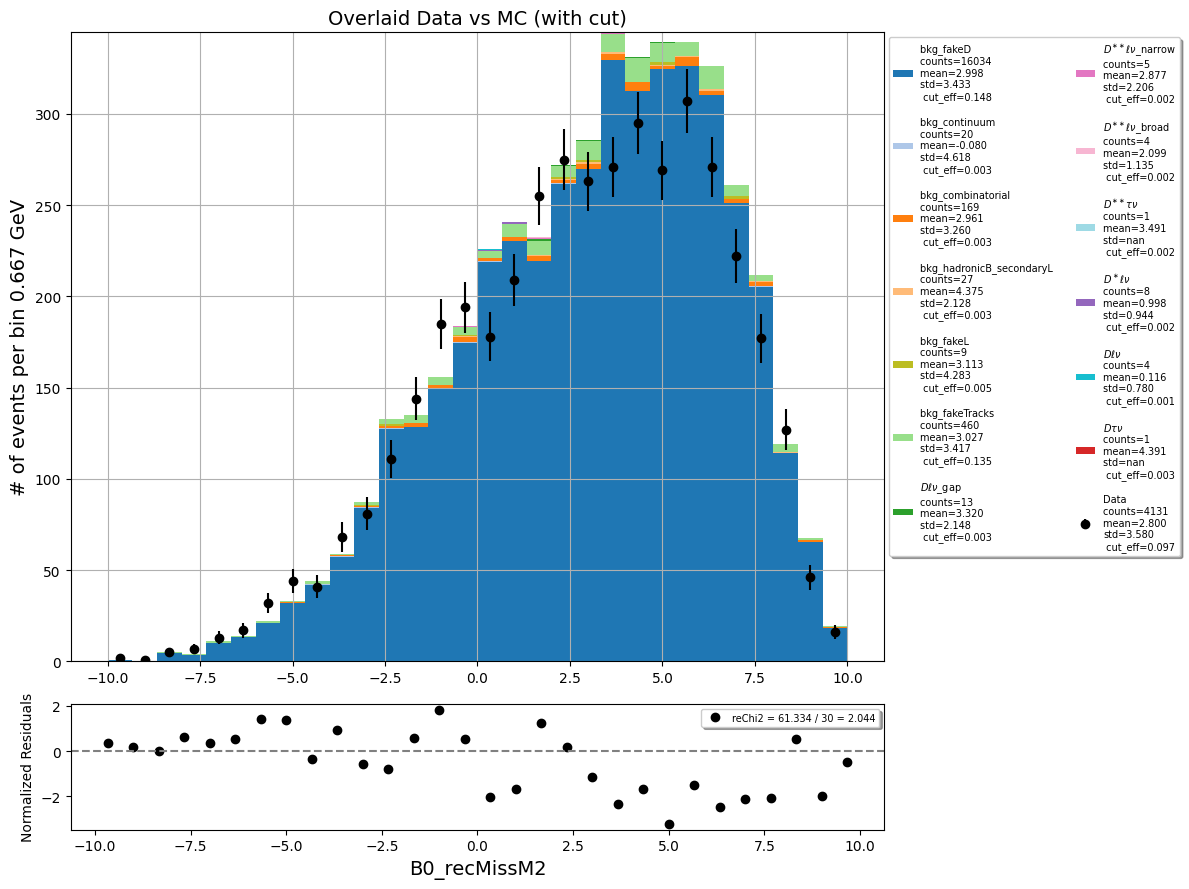

In [38]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

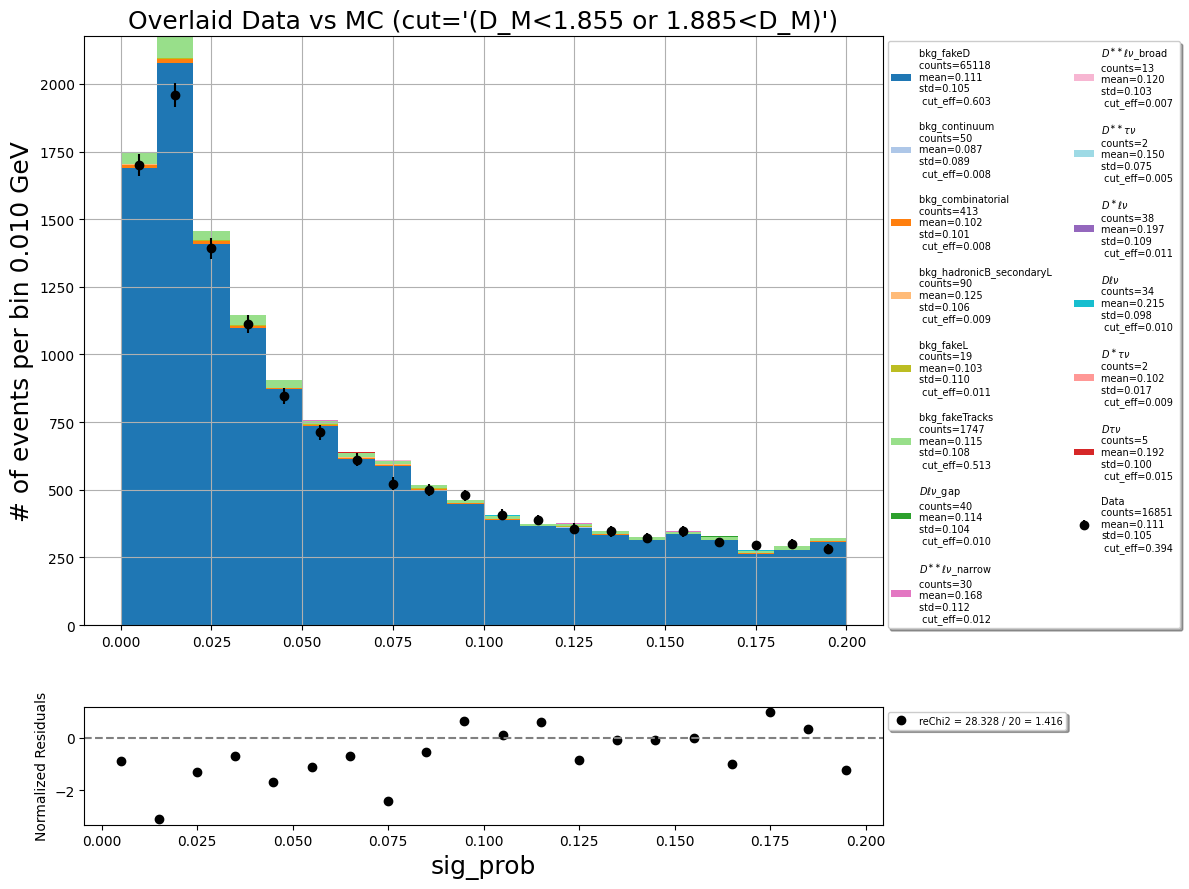

In [20]:
b1 = np.linspace(0,0.2,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='sig_prob',bins=b1,cut='(D_M<1.855 or 1.885<D_M)',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

In [44]:
samples_comb['bkg_fakeD'].query('3<B0_recMissM2<8').ell_mcPDG.value_counts()

ell_mcPDG
-11.0      26053
 11.0      25938
 211.0       730
-211.0       646
-321.0        71
 321.0        64
-13.0         19
 13.0         11
-2212.0        6
 2212.0        1
Name: count, dtype: int64

In [45]:
730/26053

0.028019805780524317

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


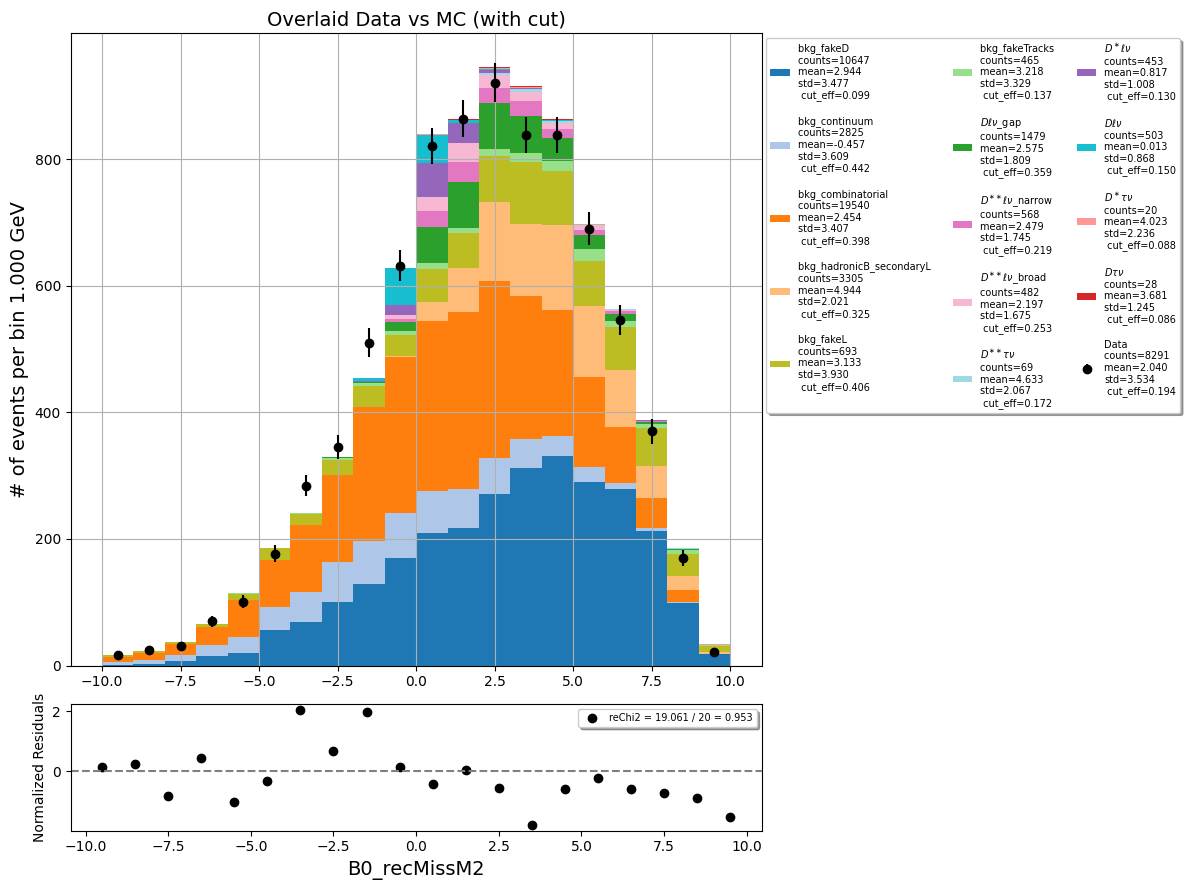

In [14]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 1,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}

data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


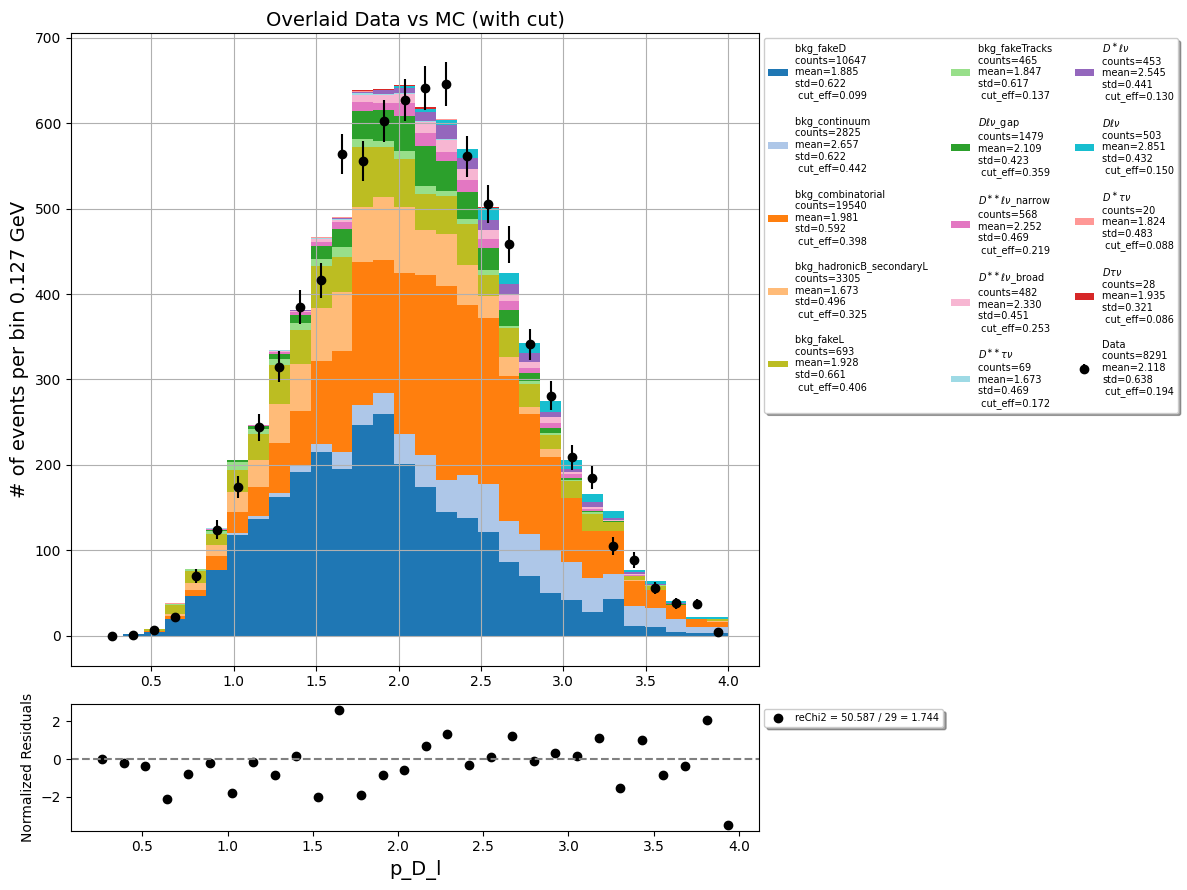

In [15]:
b1 = np.linspace(0.2,4,31)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 1,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


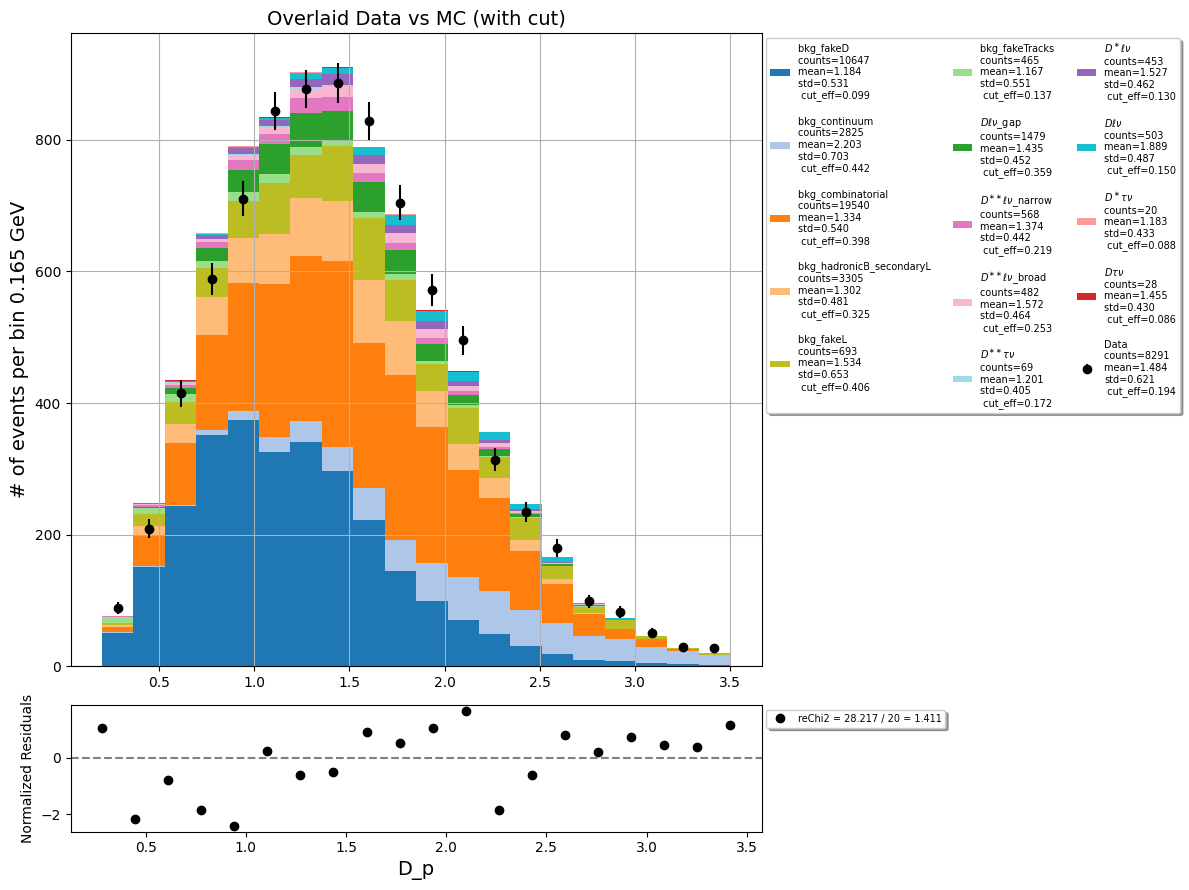

In [13]:
b1 = np.linspace(0.2,3.5,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 1,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='D_p',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


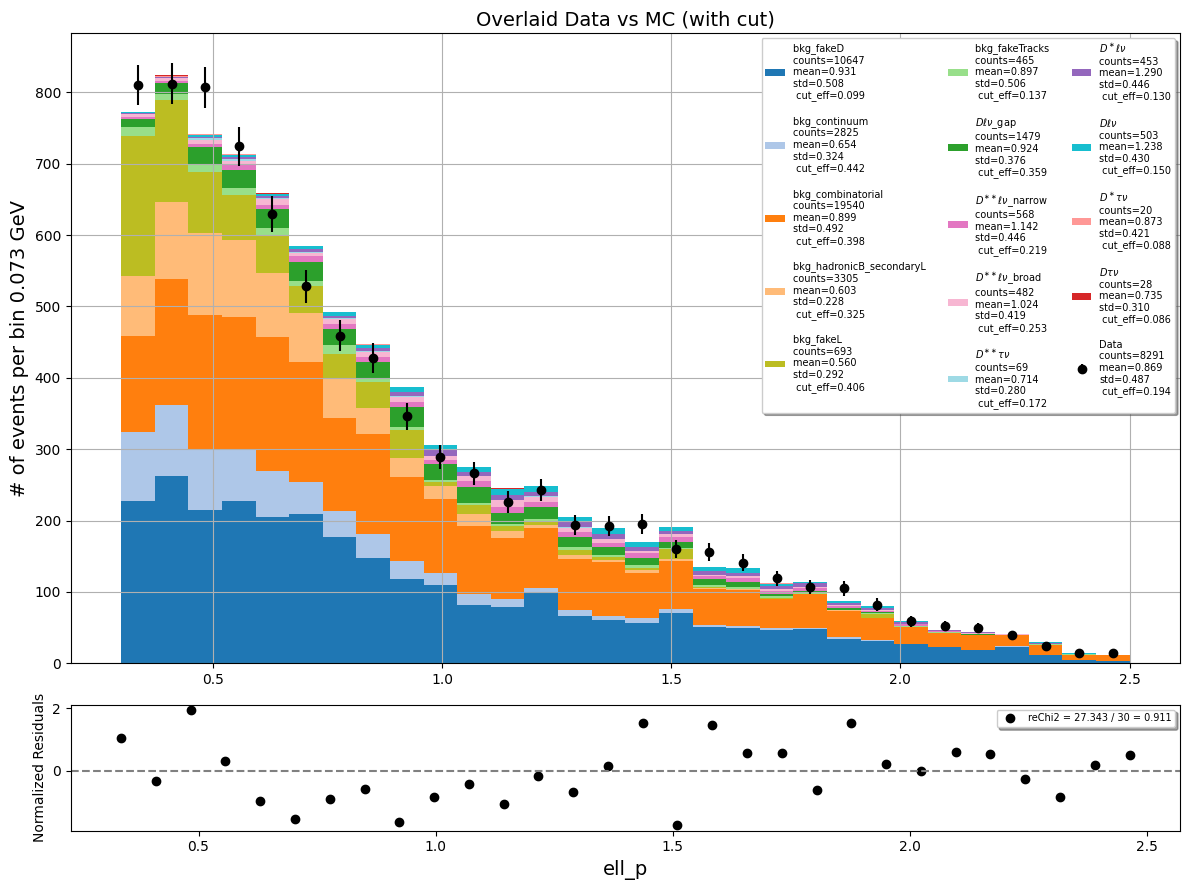

In [12]:
b1 = np.linspace(0.3,2.5,31)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 1,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

### b. Plot ROE variables

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


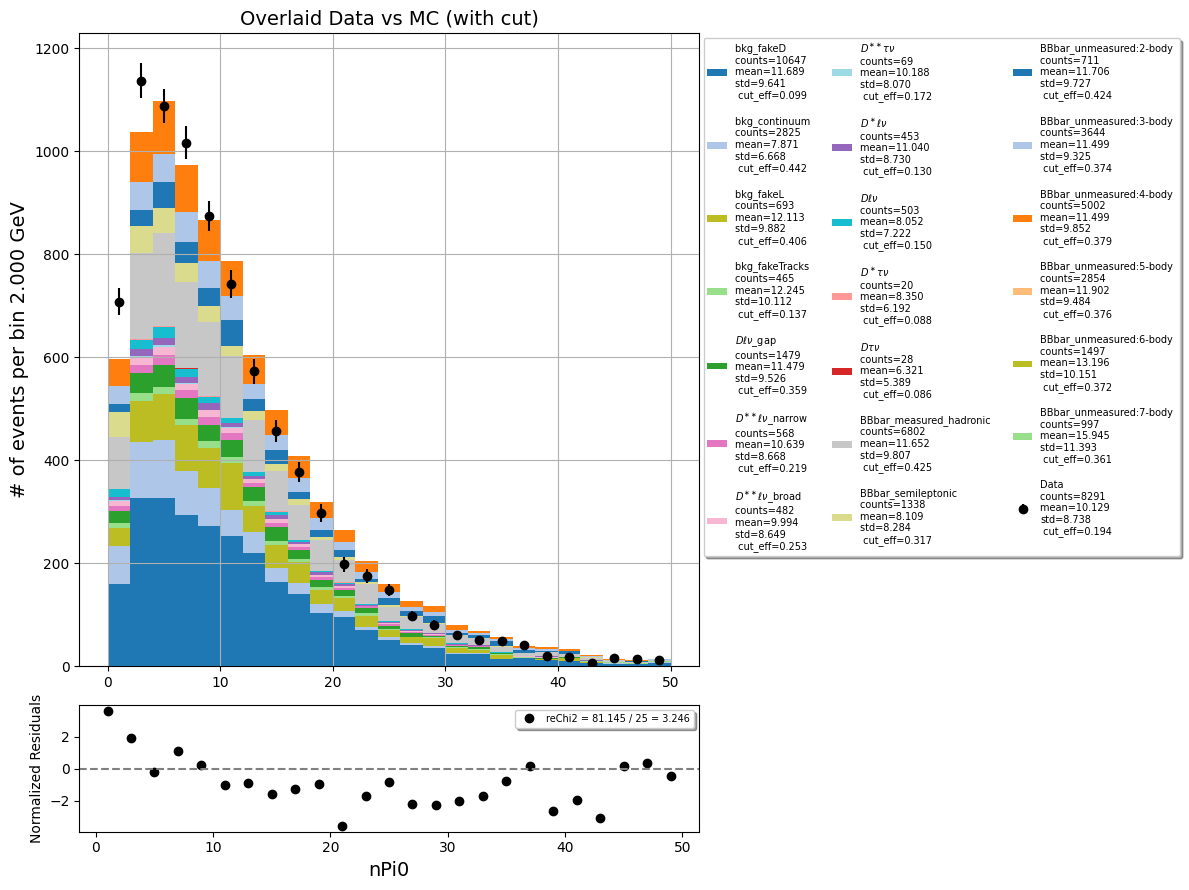

In [17]:
b1 = np.linspace(0,50,26)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.96,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.84,
         'BBbar_unmeasured:3-body':0.25 * 0.65,
         'BBbar_unmeasured:4-body':0.25 * 0.78,
         'BBbar_unmeasured:5-body':0.25 * 0,
         'BBbar_unmeasured:6-body':0.25 * 0,
         'BBbar_unmeasured:7-body':0.25 * 0,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='nPi0',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


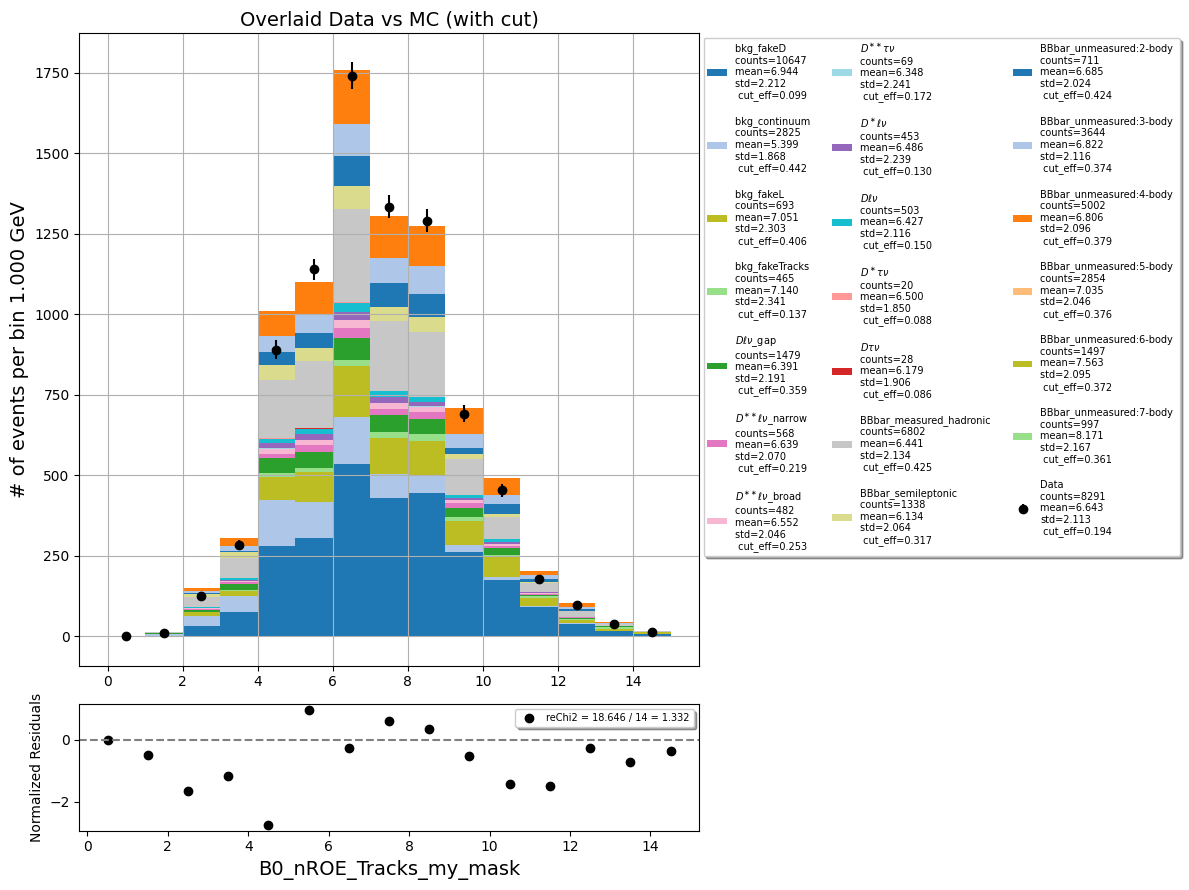

In [18]:
b1 = np.linspace(0,15,16)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.96,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.84,
         'BBbar_unmeasured:3-body':0.25 * 0.65,
         'BBbar_unmeasured:4-body':0.25 * 0.78,
         'BBbar_unmeasured:5-body':0.25 * 0,
         'BBbar_unmeasured:6-body':0.25 * 0,
         'BBbar_unmeasured:7-body':0.25 * 0,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_nROE_Tracks_my_mask',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

### c. Subtract the fakeD

cut= fakeD_prob<0.1 and sig_prob<0.1


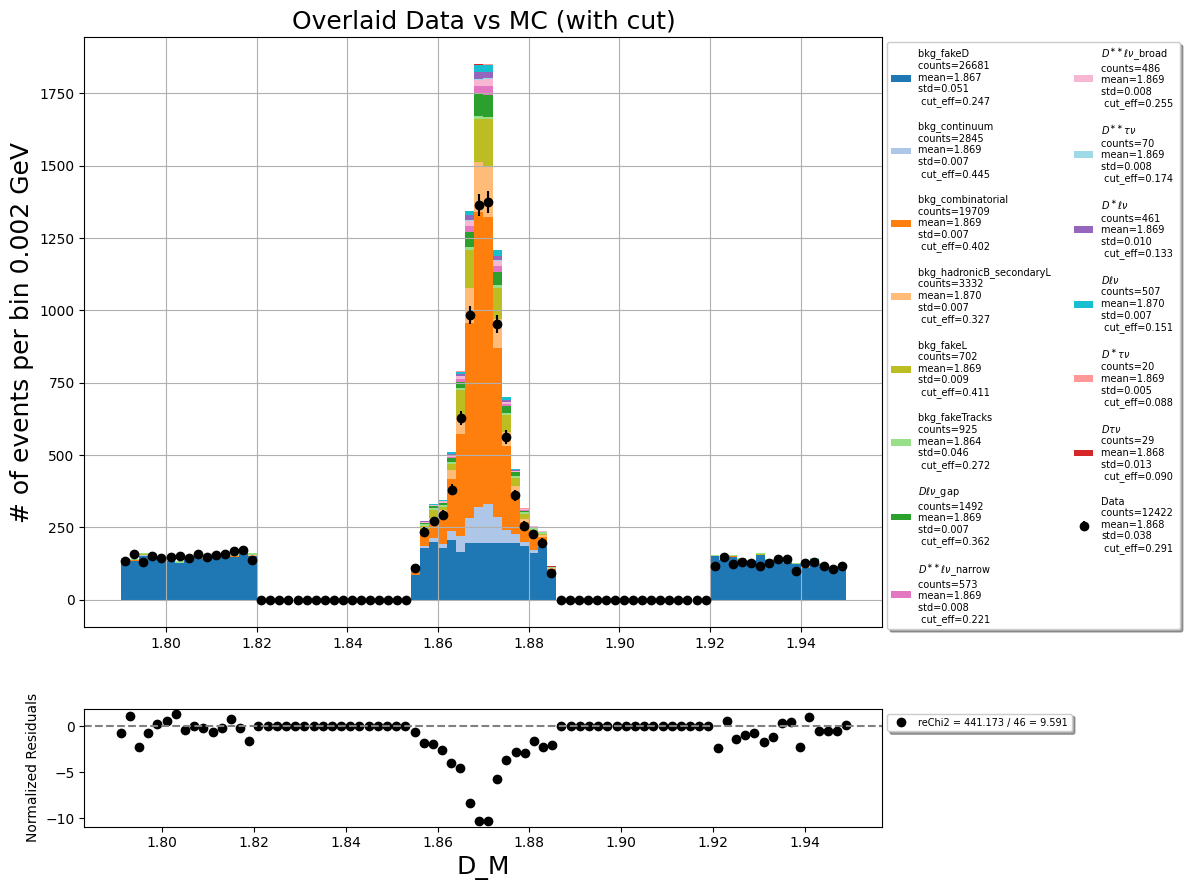

In [21]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut='fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

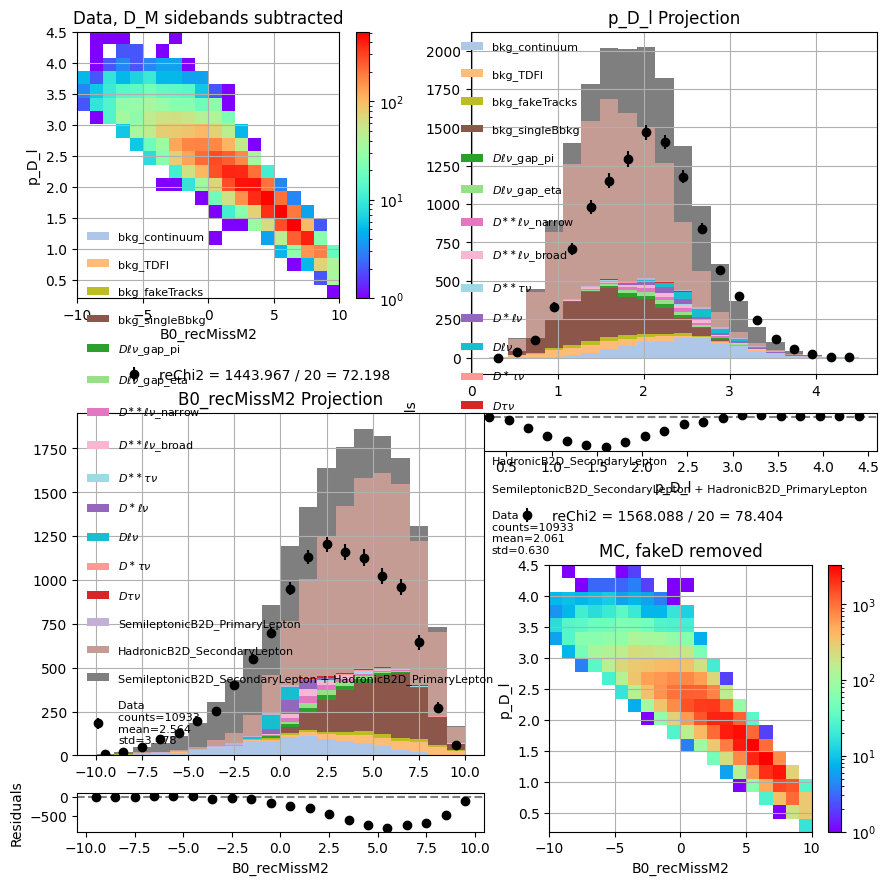

In [18]:
# e channel, lgb_comb
b_mm2 = np.linspace(-10,10,21)
b_pDl = np.linspace(0.2,4.5,21)
scale = {'data left sideband': 5580/5943/2,
         'data right sideband': 5580/5218/2,
         'data signal region': 1,
         'all_mc': 0.25}

par_dict={'var_list':['B0_recMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_vtxReChi2>3', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl_comb_subcat.plot_data_subtracted_and_mc(**par_dict)

In [ ]:
# mu channel
b_mm2 = np.linspace(-13,10,21)
b_pDl = np.linspace(0.2,5,21)
scale = {'data left sideband': 2209/2351/2 * 200/187,
         'data right sideband': 2209/2066/2 * 200/187,
         'data signal region': 200/187}

par_dict={'var_list':['B0_CMS3_weMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_vtxReChi2>5', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl_comb.plot_data_subtracted_and_mc(**par_dict)

### d.  Fit the combinatorial components

In [7]:
MM2_bins = np.linspace(-10,10,41)
p_D_l_bins = np.linspace(0.2,4,41)
MM2_bins_sb = np.linspace(-10,10,21)
p_D_l_bins_sb = np.linspace(0.2,4,21)
    
temp_data_sr,temp_data_sb,temp_data_sr_merged, temp_data_sb_merged = util.create_templates_new(
    samples=samples_comb_sub,cut='fakeD_prob<0.1 and sig_prob<0.1',variables=['B0_recMissM2','p_D_l'],
    bins_sr=[MM2_bins, p_D_l_bins],bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
     scale_lumi=1, bin_threshold=10,merge_threshold=5,
    use_real_data_instead_of_asimov=True, real_data=df_data_4S_comb,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight',
    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal', 'others',
                      r'$D\ell\nu$_gap',
                       # 'bkg_fakeD', 
                       # 'bkg_continuum',
#                       r'$D^{\ast\ast}\ell\nu$_broad',
#                       r'$D^{\ast\ast}\ell\nu$_narrow',
#                       r'$D\ell\nu$',
#                       r'$D^\ast\ell\nu$',
#                       r'$D\tau\nu$', 
#                       r'$D^\ast\tau\nu$', 
#                       r'$D^{\ast\ast}\tau\nu$',
                      #  'bkg_fakeTracks',
                      # 'bkg_TDFl','bkg_singleBbkg',
                      # 'bkg_combinatorial',
                      ],
    sample_weights={#r'$D\ell\nu$_gap_pi':           0, # 2618 events 
                    r'$D\ell\nu$_gap':          0, # 2404
                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435, # 11540 events from 1/ab
                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25,
                    r'$D\ell\nu$':                  0.25,
                    r'$D^\ast\ell\nu$':             0.25,
                    r'$D\tau\nu$':                  0.25 , 
                    r'$D^\ast\tau\nu$':             0.25 , 
                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33,
                    'bkg_fakeD':                    0.25, # here for signal region
                    'bkg_fakeL':                    0.25,
                    'bkg_continuum':                0.25,
                    'bkg_combinatorial':            0.25,
                    'bkg_hadronicB_secondaryL':     0.25,
                    'bkg_fakeTracks':               0.25,
                    'BBbar_measured_hadronic':      0.25,
                    'BBbar_semileptonic':           0.25,
                    'BBbar_unmeasured:2-body':      0.25,
                    'BBbar_unmeasured:3-body':      0.25,
                    'BBbar_unmeasured:4-body':      0.25,
                    'BBbar_unmeasured:5-body':      0.25,
                    'BBbar_unmeasured:6-body':      0.25,
                    'BBbar_unmeasured:7-body':      0.25,
                    'BBbar_unmeasured:5+-body':     0.25,
                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 237, new template (merge small bins) length = 237
creating new templates with merged bins in the D mass sidebands, original template length = 76, new template (merge small bins) length = 76


In [8]:
import json
spec_comb_e = util.create_workspace(temp_data_channels=[temp_data_sr,temp_data_sb],mc_uncer=True,fakeD_uncer=True)
spec_comb_e['measurements'][0]['config']['poi']="BBbar_measured_hadronic_norm"
print(json.dumps(spec_comb_e, sort_keys=True, indent=4))

{
    "channels": [
        {
            "name": "channel_0",
            "samples": [
                {
                    "data": [
                        1.7,
                        1.81,
                        3.06,
                        1.2,
                        2.4,
                        1.59,
                        23.85,
                        3.86,
                        4.6,
                        2.96,
                        2.33,
                        8.97,
                        3.7,
                        5.11,
                        2.91,
                        3.52,
                        2.57,
                        3.17,
                        6.09,
                        4.26,
                        7.0,
                        4.63,
                        3.6,
                        2.62,
                        2.69,
                        1.88,
                        6.1,
                        4.88,
                        8.75,
 

In [9]:
import cabinetry, pyhf
cabinetry.set_logging()

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_measured_hadronic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_semileptonic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:2-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:3-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:4-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:5+-body_norm (1 new nuisance para

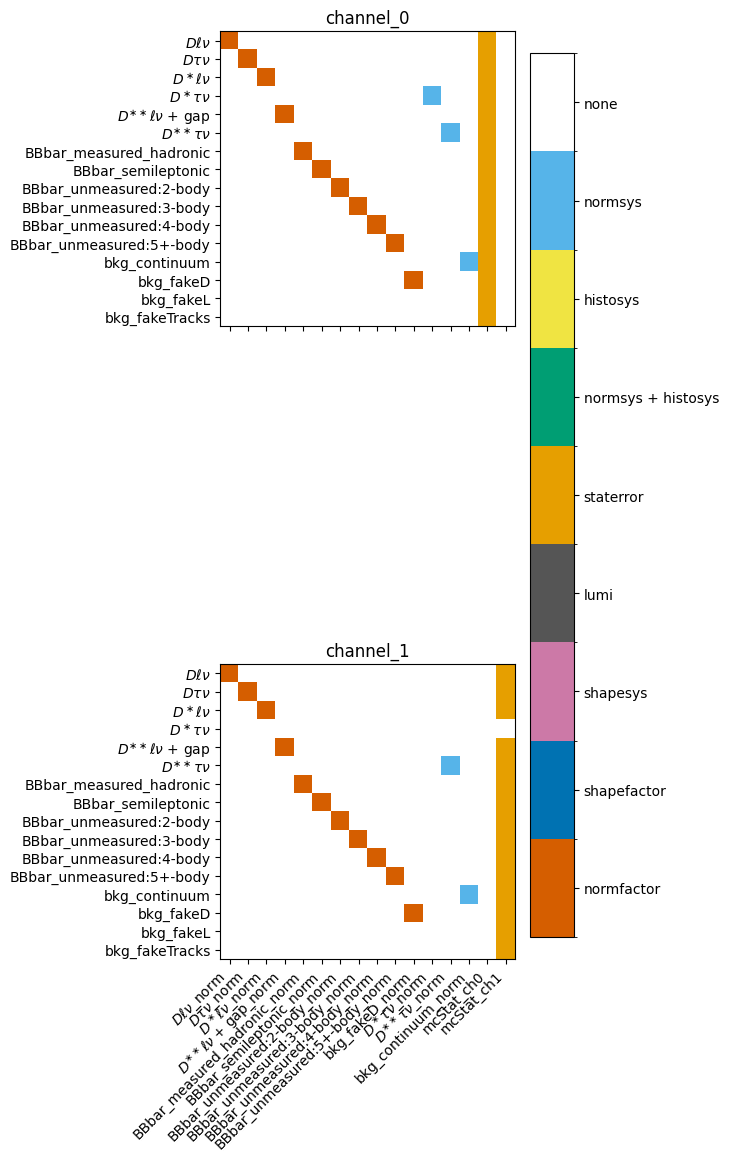

In [10]:
model_comb_e, data_comb_e = cabinetry.model_utils.model_and_data(spec_comb_e)
pars = model_comb_e.config.suggested_init()

norm_parameter_names = [par for par in model_comb_e.config.par_order if par.endswith('_norm')]
for par in norm_parameter_names:
    model_comb_e.config.param_set(par).suggested_bounds=[[0,5]]
    # if par=='SemileptonicB2D_PrimaryLepton_norm':
    #     model_comb.config.param_set(par).suggested_bounds=[[-0.9,1.1]]
    if par.startswith('$'):
        model_comb_e.config.param_set(par).suggested_fixed=[True]

model_comb_e.config.param_set('bkg_fakeD_norm').suggested_fixed=[False]
model_comb_e.config.param_set('bkg_continuum_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_semileptonic_norm').suggested_fixed=[True]
model_comb_e.config.param_set('BBbar_measured_hadronic_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_init=[1]
model_comb_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_init=[1]
model_comb_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:4-body_norm').suggested_init=[0.68]
# model_comb_e.config.param_set('BBbar_unmeasured:5-body_norm').suggested_init=[0.1]
# model_comb_e.config.param_set('BBbar_unmeasured:6-body_norm').suggested_init=[0.1]
# model_comb_e.config.param_set('BBbar_unmeasured:7-body_norm').suggested_init=[0.1]
model_comb_e.config.param_set('BBbar_unmeasured:5+-body_norm').suggested_init=[0.1]

cabinetry.visualize.modifier_grid(model_comb_e)
# cabinetry.visualize.modifier_grid(pyhf.Workspace(spec_comb_e).model())

In [11]:
%%time
# e mode, staterror
fit_results = cabinetry.fit.fit(model=model_comb_e, data=data_comb_e,goodness_of_fit=True,
#                                 init_pars=[1]*7+[10]*3+pars[10:],
                                # fix_pars=[True]*4
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1178                       │            Nfcn = 122981             │
│ EDM = 1.79e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

CPU times: user 53 s, sys: 79.9 ms, total: 53.1 s
Wall time: 53.3 s
